In [ ]:
!pip install ultralytics pandas matplotlib -q

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1-3, nbs=64, nms=False, opset=None, optimize=False

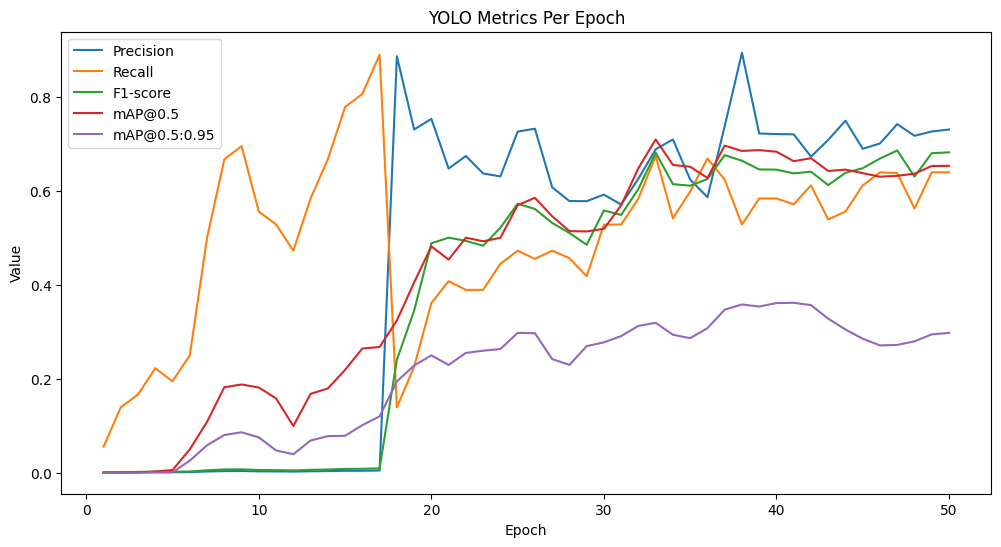

In [12]:
# ==========================================
# INSTALL LIBRARIES
# ==========================================
# !pip install ultralytics pandas matplotlib -q

# ==========================================s
# IMPORTS
# ==========================================
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD MODEL
# ==========================================
model = YOLO("/content/drive/MyDrive/yolo26n.pt")   # replace with your model

# ==========================================
# TRAIN MODEL
# ==========================================
results = model.train(
    data="/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml",     # dataset yaml
    epochs=50,
    imgsz=640,
    batch=16,
    project="yolo_training",
    name="exp1"
)

# ==========================================
# LOAD TRAINING CSV
# Ultralytics automatically saves metrics
# after every epoch in results.csv
# ==========================================
# Correcting the csv_path to reflect the actual training run output directory
csv_path = "/content/runs/detect/yolo_training/exp1-2/results.csv"

df = pd.read_csv(csv_path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================
# EXTRACT METRICS
# ==========================================
epochs = df["epoch"]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
map5095 = df["metrics/mAP50-95(B)"]

# ==========================================
# CALCULATE F1 SCORE FOR EACH EPOCH
# ==========================================
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

# Add F1 to dataframe
df["F1-score"] = f1_score

# ==========================================
# DISPLAY TABLE
# ==========================================
final_table = pd.DataFrame({
    "Epoch": epochs,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP@0.5": map50,
    "mAP@0.5:0.95": map5095
})

print(final_table)

# ==========================================
# SAVE TABLE
# ==========================================
final_table.to_csv("epoch_metrics.csv", index=False)

print("\nSaved as epoch_metrics.csv")

# ==========================================
# PLOT METRICS
# ==========================================
plt.figure(figsize=(12,6))

plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1_score, label="F1-score")
plt.plot(epochs, map50, label="mAP@0.5")
plt.plot(epochs, map5095, label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLO Metrics Per Epoch")
plt.legend()

plt.show()

### Model Parameters and Floating Point Operations (FLOPs)

In [8]:
print(model.info())

YOLO26n summary: 260 layers, 2,504,190 parameters, 0 gradients, 5.8 GFLOPs
(260, 2504190, 0, 5.771775999999999)


Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1-5, nbs=64, nms=False, opset=None, optimize=Fals

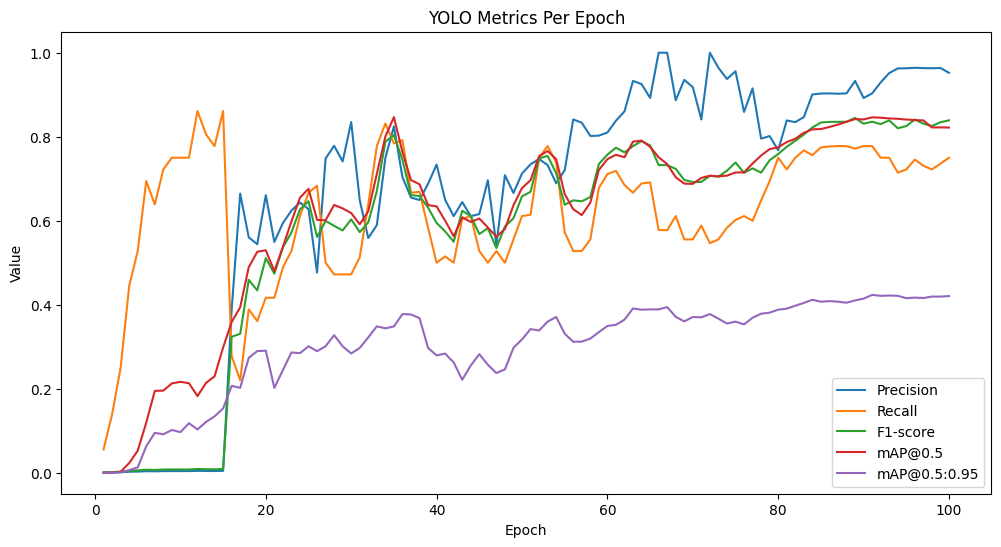

In [14]:
# ==========================================
# INSTALL LIBRARIES
# ==========================================
# !pip install ultralytics pandas matplotlib -q

# ==========================================s
# IMPORTS
# ==========================================
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================s
# LOAD MODEL
# ==========================================
model = YOLO("/content/drive/MyDrive/yolo26n.pt")   # replace with your model

# ==========================================s
# TRAIN MODEL
# ==========================================
results = model.train(
    data="/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml",     # dataset yaml
    epochs=100,
    imgsz=640,
    batch=16,
    project="yolo_training",
    name="exp1"
)

# ==========================================s
# LOAD TRAINING CSV
# Ultralytics automatically saves metrics
# after every epoch in results.csv
# ==========================================s
# Dynamically get the save_dir from the training results
if hasattr(results, 'save_dir') and results.save_dir:
    training_save_dir = str(results.save_dir)
else:
    # Fallback if save_dir is not directly available or results object structure changes
    # This assumes a consistent naming convention like 'exp', 'exp2', etc.
    runs_dir = '/content/runs/detect/yolo_training'
    existing_exps = [d for d in os.listdir(runs_dir) if d.startswith('exp') and os.path.isdir(os.path.join(runs_dir, d))]
    if existing_exps:
        # Sort to get the latest one (e.g., exp1-4 instead of exp1-3)
        # Extract numeric part for sorting, handle cases like 'exp' vs 'exp1-2'
        def sort_key(x):
            parts = x.split('-')
            if len(parts) > 1 and parts[1].isdigit():
                return int(parts[1])
            return 0 # For 'exp1' or 'exp' which might be treated as 'exp1-0'
        latest_exp = sorted(existing_exps, key=sort_key)[-1]
        training_save_dir = os.path.join(runs_dir, latest_exp)
    else:
        training_save_dir = os.path.join(runs_dir, 'exp') # Default if no exp folders exist

csv_path = os.path.join(training_save_dir, "results.csv")

df = pd.read_csv(csv_path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================s
# EXTRACT METRICS
# ==========================================s
epochs = df["epoch"]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
map5095 = df["metrics/mAP50-95(B)"]

# ==========================================s
# CALCULATE F1 SCORE FOR EACH EPOCH
# ==========================================s
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

# Add F1 to dataframe
df["F1-score"] = f1_score

# ==========================================s
# DISPLAY TABLE
# ==========================================s
final_table = pd.DataFrame({
    "Epoch": epochs,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP@0.5": map50,
    "mAP@0.5:0.95": map5095
})

print(final_table)

# ==========================================s
# SAVE TABLE
# ==========================================s
final_table.to_csv("epoch_metrics100.csv", index=False)

print("\nSaved as epoch_metrics100.csv")

# ==========================================s
# PLOT METRICS
# ==========================================s
plt.figure(figsize=(12,6))

plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1_score, label="F1-score")
plt.plot(epochs, map50, label="mAP@0.5")
plt.plot(epochs, map5095, label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLO Metrics Per Epoch")
plt.legend()

plt.show()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1-8, nbs=64, nms=False, opset=None, optimize=Fals

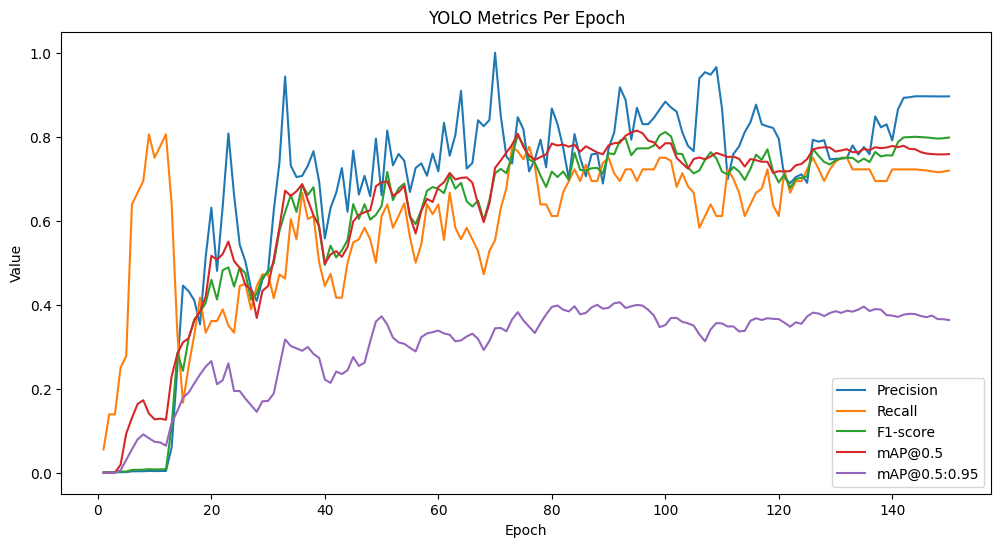

In [2]:
# ==========================================
# INSTALL LIBRARIES
# ==========================================
# !pip install ultralytics pandas matplotlib -q

# ==========================================s
# IMPORTS
# ==========================================
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================s
# LOAD MODEL
# ==========================================
model = YOLO("/content/drive/MyDrive/yolo26n.pt")   # replace with your model

# ==========================================s
# TRAIN MODEL
# ==========================================
results = model.train(
    data="/content/drive/MyDrive/Brain Tumor.v1i.yolo26/data.yaml",     # dataset yaml
    epochs=150,
    imgsz=640,
    batch=16,
    project="yolo_training",
    name="exp1"
)

# ==========================================s
# LOAD TRAINING CSV
# Ultralytics automatically saves metrics
# after every epoch in results.csv
# ==========================================s
# Dynamically get the save_dir from the training results
if hasattr(results, 'save_dir') and results.save_dir:
    training_save_dir = str(results.save_dir)
else:
    # Fallback if save_dir is not directly available or results object structure changes
    # This assumes a consistent naming convention like 'exp', 'exp2', etc.
    runs_dir = '/content/runs/detect/yolo_training'
    existing_exps = [d for d in os.listdir(runs_dir) if d.startswith('exp') and os.path.isdir(os.path.join(runs_dir, d))]
    if existing_exps:
        # Sort to get the latest one (e.g., exp1-4 instead of exp1-3)
        # Extract numeric part for sorting, handle cases like 'exp' vs 'exp1-2'
        def sort_key(x):
            parts = x.split('-')
            if len(parts) > 1 and parts[1].isdigit():
                return int(parts[1])
            return 0 # For 'exp1' or 'exp' which might be treated as 'exp1-0'
        latest_exp = sorted(existing_exps, key=sort_key)[-1]
        training_save_dir = os.path.join(runs_dir, latest_exp)
    else:
        training_save_dir = os.path.join(runs_dir, 'exp') # Default if no exp folders exist

csv_path = os.path.join(training_save_dir, "results.csv")

df = pd.read_csv(csv_path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# ==========================================s
# EXTRACT METRICS
# ==========================================s
epochs = df["epoch"]

precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
map5095 = df["metrics/mAP50-95(B)"]

# ==========================================s
# CALCULATE F1 SCORE FOR EACH EPOCH
# ==========================================s
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

# Add F1 to dataframe
df["F1-score"] = f1_score

# ==========================================s
# DISPLAY TABLE
# ==========================================s
final_table = pd.DataFrame({
    "Epoch": epochs,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP@0.5": map50,
    "mAP@0.5:0.95": map5095
})

print(final_table)

# ==========================================s
# SAVE TABLE
# ==========================================s
final_table.to_csv("epoch_metrics150.csv", index=False)

print("\nSaved as epoch_metrics150.csv")

# ==========================================s
# PLOT METRICS
# ==========================================s
plt.figure(figsize=(12,6))

plt.plot(epochs, precision, label="Precision")
plt.plot(epochs, recall, label="Recall")
plt.plot(epochs, f1_score, label="F1-score")
plt.plot(epochs, map50, label="mAP@0.5")
plt.plot(epochs, map5095, label="mAP@0.5:0.95")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("YOLO Metrics Per Epoch")
plt.legend()

plt.show()